In [2]:
import pandas as pd

# CSV dosyasını okuyalım
df = pd.read_csv("otel_temizlik_veriseti_2025-05-14_23-04-04.csv")

# Veri setinin ilk birkaç satırını ve sütun başlıklarını görüntüleyelim
df.head()

,Tarih,Oda Numarası,Oda Tipi,Personel ID,Temizlik Türü,Giriş Saati,Çıkış Saati
0,2024-01-01,144,Standart,P004,Rutin,10:22,10:42
1,2024-01-01,144,Standart,M001,Mini Bar,10:15,10:19
2,2024-01-01,151,Standart,P003,Rutin,10:15,10:23
3,2024-01-01,151,Standart,M001,Mini Bar,10:56,11:01
4,2024-01-01,135,Standart,P003,Rutin,10:28,10:38


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307731 entries, 0 to 307730
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Tarih          307731 non-null  object
 1   Oda Numarası   307731 non-null  int64 
 2   Oda Tipi       307731 non-null  object
 3   Personel ID    307731 non-null  object
 4   Temizlik Türü  307731 non-null  object
 5   Giriş Saati    307731 non-null  object
 6   Çıkış Saati    307731 non-null  object
dtypes: int64(1), object(6)
memory usage: 16.4+ MB


In [6]:
df['Tarih'] = pd.to_datetime(df['Tarih'])

df['Giriş Saati'] = pd.to_datetime(df['Giriş Saati'], format='%H:%M').dt.time
df['Çıkış Saati'] = pd.to_datetime(df['Çıkış Saati'], format='%H:%M').dt.time

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307731 entries, 0 to 307730
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Tarih          307731 non-null  datetime64[ns]
 1   Oda Numarası   307731 non-null  int64         
 2   Oda Tipi       307731 non-null  object        
 3   Personel ID    307731 non-null  object        
 4   Temizlik Türü  307731 non-null  object        
 5   Giriş Saati    307731 non-null  object        
 6   Çıkış Saati    307731 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 16.4+ MB


In [8]:
df.head()

,Tarih,Oda Numarası,Oda Tipi,Personel ID,Temizlik Türü,Giriş Saati,Çıkış Saati
0,2024-01-01,144,Standart,P004,Rutin,10:22:00,10:42:00
1,2024-01-01,144,Standart,M001,Mini Bar,10:15:00,10:19:00
2,2024-01-01,151,Standart,P003,Rutin,10:15:00,10:23:00
3,2024-01-01,151,Standart,M001,Mini Bar,10:56:00,11:01:00
4,2024-01-01,135,Standart,P003,Rutin,10:28:00,10:38:00


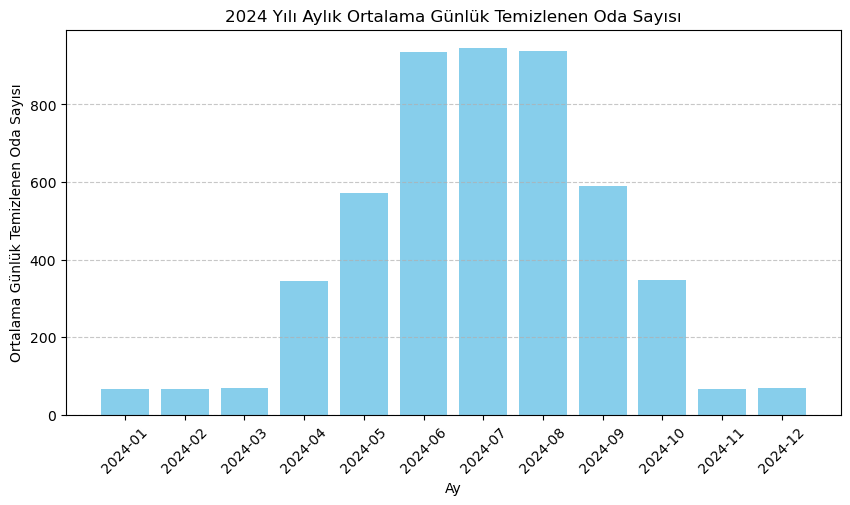

In [10]:
import matplotlib.pyplot as plt

gunluk_temizlenen_oda_sayisi = df.groupby('Tarih')['Oda Numarası'].nunique().reset_index()
gunluk_temizlenen_oda_sayisi.columns = ['Tarih', 'Günlük Temizlenen Oda Sayısı']
gunluk_temizlenen_oda_sayisi['Ay'] = pd.to_datetime(gunluk_temizlenen_oda_sayisi['Tarih']).dt.to_period('M')

aylik_ortalama_temizlik = (
    gunluk_temizlenen_oda_sayisi.groupby('Ay')['Günlük Temizlenen Oda Sayısı'].mean().reset_index()
)
aylik_ortalama_temizlik.columns = ['Ay', 'Ortalama Günlük Temizlenen Oda Sayısı']

# Grafiği oluşturma
plt.figure(figsize=(10, 5))
plt.bar(aylik_ortalama_temizlik["Ay"].astype(str), aylik_ortalama_temizlik["Ortalama Günlük Temizlenen Oda Sayısı"], color="skyblue")

# Grafik başlık ve etiketleri
plt.title("2024 Yılı Aylık Ortalama Günlük Temizlenen Oda Sayısı")
plt.xlabel("Ay")
plt.ylabel("Ortalama Günlük Temizlenen Oda Sayısı")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Grafiği gösterme
plt.show()


In [12]:
import pandas as pd

# Çalışanları sınıflandırma
df['Personel Tipi'] = df['Personel ID'].apply(lambda x: 'Arıza Personeli' if x.startswith('A') 
                                              else 'Temizlik Personeli' if x.startswith('P') 
                                              else 'Mini Bar Görevlisi' if x.startswith('M') 
                                              else 'Diğer')

# Her personel tipinin kaç farklı çalışanı olduğunu hesaplayalım
personel_sayilari = df.groupby('Personel Tipi')['Personel ID'].nunique().reset_index()
personel_sayilari.columns = ['Personel Tipi', 'Personel Sayısı']

# Tabloyu görüntüleyelim
personel_sayilari.head()

,Personel Tipi,Personel Sayısı
0,Arıza Personeli,10
1,Mini Bar Görevlisi,32
2,Temizlik Personeli,90


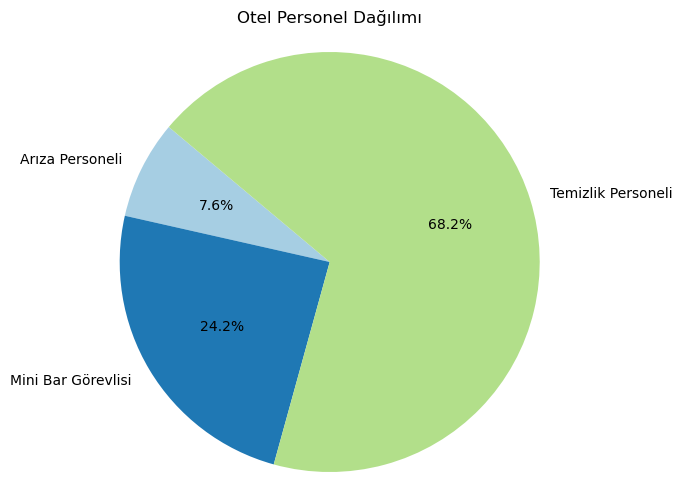

In [14]:
import matplotlib.pyplot as plt

# Pasta grafiği oluşturma
plt.figure(figsize=(8, 6))
plt.pie(personel_sayilari["Personel Sayısı"],
        labels=personel_sayilari["Personel Tipi"],
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Paired.colors)

# Grafik başlığı
plt.title("Otel Personel Dağılımı")

# Daireyi eşit yapmak için
plt.axis('equal')

# Grafiği gösterme
plt.show()

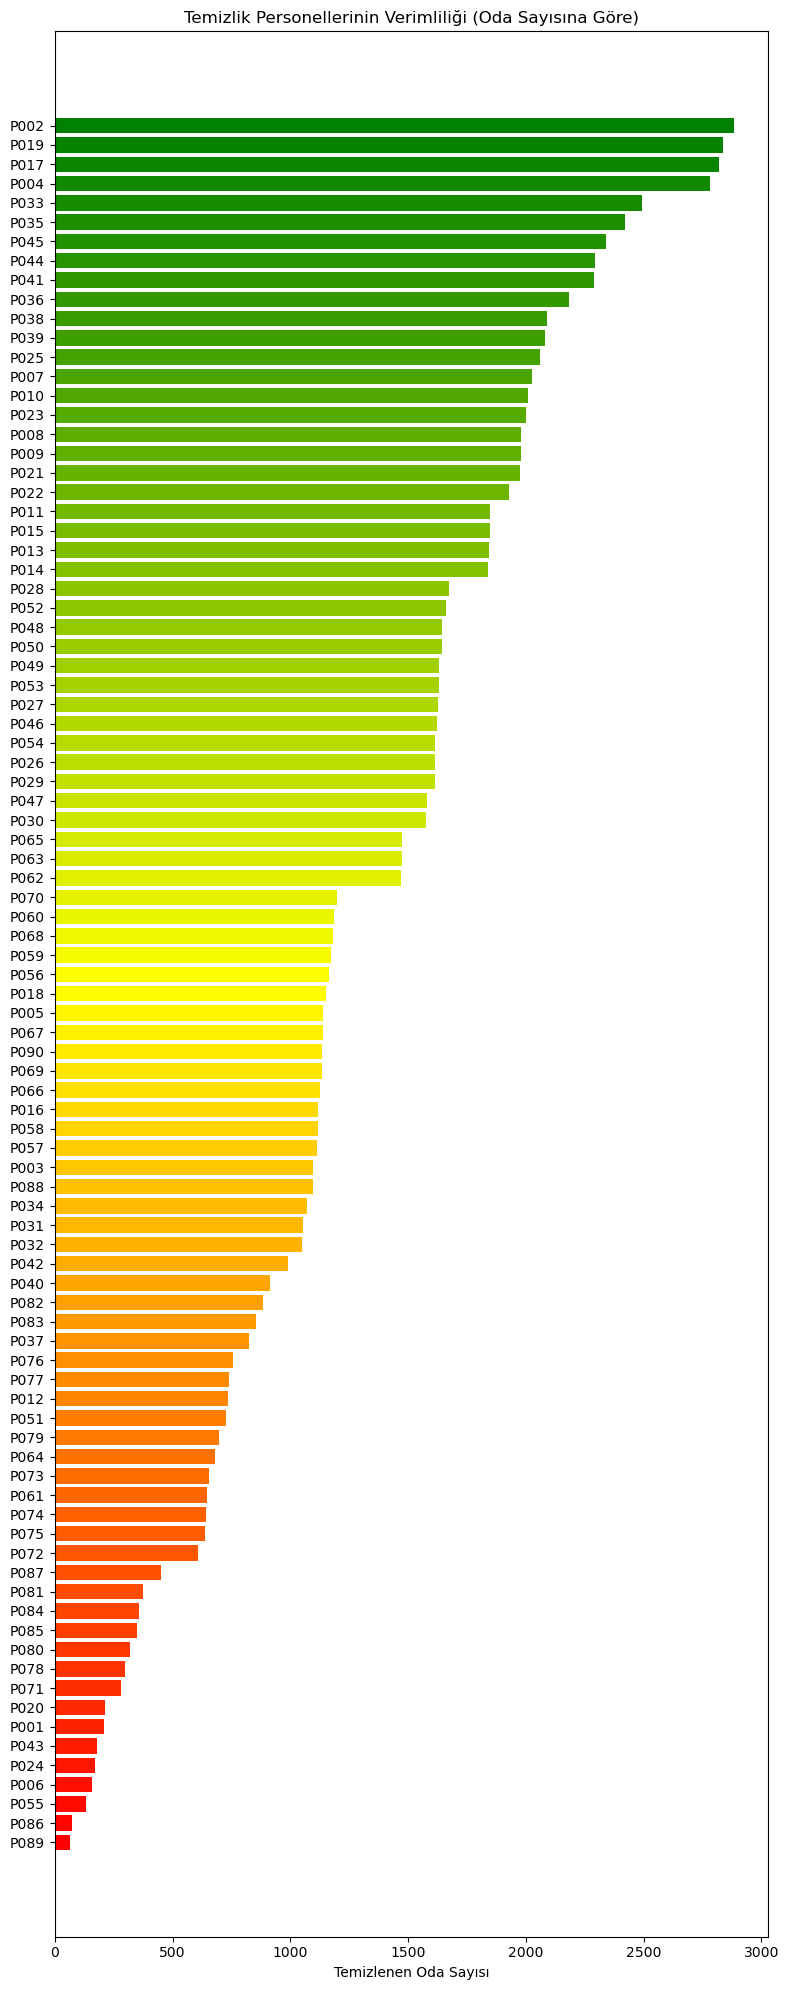

In [16]:
import matplotlib.colors as mcolors
import numpy as np

# Sadece temizlik personellerini al ("Rutin" temizlik türüne göre filtreleme)
temizlik_df = df[df['Temizlik Türü'] == 'Rutin']

# Personel ID'ye göre kaç oda temizlediklerini say
oda_sayilari = temizlik_df['Personel ID'].value_counts()

# Sıralamayı büyükten küçüğe yap
oda_sayilari_sorted = oda_sayilari.sort_values(ascending=False)

# Renk skalası oluştur (yeşilden kırmızıya doğru)
cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["green", "yellow", "red"])
renkler = [cmap(i / (len(oda_sayilari_sorted) - 1)) for i in range(len(oda_sayilari_sorted))]

# Grafik çizimi
fig, ax = plt.subplots(figsize=(8, 20))
bars = ax.barh(oda_sayilari_sorted.index, oda_sayilari_sorted.values, color=renkler)
ax.invert_yaxis()  # En çok çalışan üstte olsun
ax.set_xlabel("Temizlenen Oda Sayısı")
ax.set_title("Temizlik Personellerinin Verimliliği (Oda Sayısına Göre)")

plt.tight_layout()
plt.show()


In [17]:
# Giriş ve çıkış saatlerini tarih ile birleştirerek tam datetime objelerine dönüştür
df['Giriş Datetime'] = pd.to_datetime(df['Tarih'].astype(str) + ' ' + df['Giriş Saati'].astype(str), errors='coerce')
df['Çıkış Datetime'] = pd.to_datetime(df['Tarih'].astype(str) + ' ' + df['Çıkış Saati'].astype(str), errors='coerce')

# Süreyi dakika cinsinden hesapla
df['Süre (dk)'] = (df['Çıkış Datetime'] - df['Giriş Datetime']).dt.total_seconds() / 60

# Negatif ve sıfır süreleri filtrele
df = df[df['Süre (dk)'] > 0]

# Hizmet türüne göre istatistiksel özet hesapla
ortalama_sureler = df.groupby('Temizlik Türü')['Süre (dk)'].agg(['count', 'mean', 'min', 'max']).round(2).reset_index()
ortalama_sureler.columns = ['Temizlik Türü', 'İşlem Sayısı', 'Ortalama Süre (dk)', 'Minimum', 'Maksimum']

ortalama_sureler

,Temizlik Türü,İşlem Sayısı,Ortalama Süre (dk),Minimum,Maksimum
0,Arıza,1455,34.95,10.0,59.0
1,Detaylı,36833,31.34,11.0,81.0
2,Mini Bar,152643,4.50,3.0,6.0
3,Rutin,114652,10.10,2.0,27.0


In [19]:

# Tarihi datetime'a çevir ve hafta sonu kontrolü yap
df["Tarih"] = pd.to_datetime(df["Tarih"])
df["Gün"] = df["Tarih"].dt.day_name()
df["Hafta Sonu"] = df["Gün"].isin(["Saturday", "Sunday"])

# Temizlik türüne göre görev sayımı
pivot = pd.pivot_table(df, 
                       index="Personel ID", 
                       columns="Temizlik Türü", 
                       values="Tarih", 
                       aggfunc="count", 
                       fill_value=0)

pivot["toplam_gorev"] = pivot.sum(axis=1)

# Görev oranlarını hesapla
for col in ["Rutin", "Detaylı", "Mini Bar", "Arıza"]:
    if col in pivot.columns:
        pivot[f"{col.lower()}_oran"] = pivot[col] / pivot["toplam_gorev"]
    else:
        pivot[f"{col.lower()}_oran"] = 0.0

# Ortalama görev süresi
mean_duration = df.groupby("Personel ID")["Süre (dk)"].mean()

# Hafta içi ve hafta sonu görev sayısı
hafta_ici = df[~df["Hafta Sonu"]].groupby("Personel ID")["Tarih"].count()
hafta_sonu = df[df["Hafta Sonu"]].groupby("Personel ID")["Tarih"].count()

# Tüm verileri birleştir
features = pivot[[
    "toplam_gorev", 
    "rutin_oran", 
    "detaylı_oran", 
    "mini bar_oran", 
    "arıza_oran"
]].copy()

features["ortalama_sure"] = mean_duration
features["hafta_ici"] = hafta_ici
features["hafta_sonu"] = hafta_sonu

# Eksik değerleri sıfırla
features = features.fillna(0)

# İlk 10 satırı yazdır
print(features.head(10))

Temizlik Türü  toplam_gorev  rutin_oran  detaylı_oran  mini bar_oran  \
Personel ID                                                            
A001                    131         0.0           0.0            0.0   
A002                    156         0.0           0.0            0.0   
A003                    158         0.0           0.0            0.0   
A004                    139         0.0           0.0            0.0   
A005                    125         0.0           0.0            0.0   
A006                    144         0.0           0.0            0.0   
A007                    163         0.0           0.0            0.0   
A008                    137         0.0           0.0            0.0   
A009                    153         0.0           0.0            0.0   
A010                    149         0.0           0.0            0.0   

Temizlik Türü  arıza_oran  ortalama_sure  hafta_ici  hafta_sonu  
Personel ID                                                      
A00

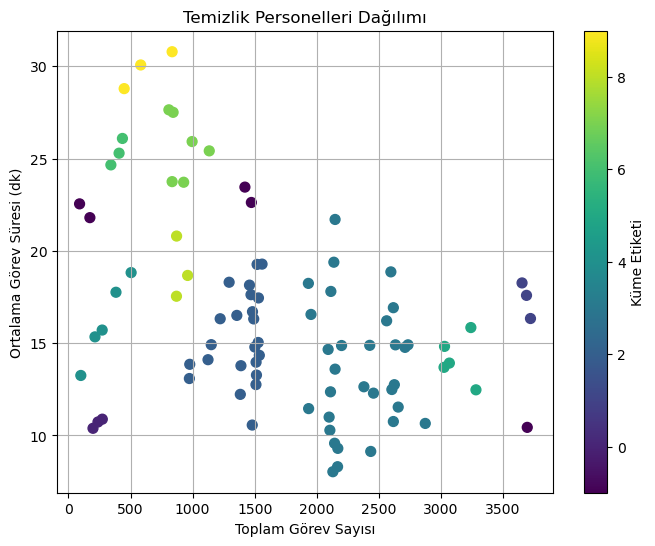

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Sadece "P" ile başlayan personeller (temizlik personelleri)
features_p = features[features.index.str.startswith("P")].copy()

# Sayısal özellikleri seç ve ölçekle
X = features_p[['toplam_gorev', 'ortalama_sure', 'hafta_ici', 'hafta_sonu']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN için parametreler: 
# eps: komşuluk yarıçapı, min_samples: minumum komşu sayısı
dbscan = DBSCAN(eps=0.5, min_samples=3)
cluster_labels = dbscan.fit_predict(X_scaled)
features_p['cluster'] = cluster_labels


plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    features_p["toplam_gorev"],
    features_p["ortalama_sure"],
    c=features_p["cluster"],
    cmap='viridis',
    s=50
)

plt.title("Temizlik Personelleri Dağılımı")
plt.xlabel("Toplam Görev Sayısı")
plt.ylabel("Ortalama Görev Süresi (dk)")
plt.colorbar(scatter, label='Küme Etiketi')
plt.grid(True)
plt.show()
